<a href="https://colab.research.google.com/github/ElihuIzanami/Introduccion-Aprendizaje-Automatico-ProyectoFinal/blob/main/Elihu_Montoya_Proyecto_Introducci%C3%B3n_al_Aprendizaje_Autom%C3%A1tico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYECTO: INTRODUCCIÓN AL APRENDIZAJE AUTOMÁTICO**

Una vez visto el ***Módulo 5: Introducción al Aprendizaje Automático***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **proyecto integrador**. En este proyecto se verá todo lo aprendido durante el **master en data science**.

Por lo que, el procedimiento a resolver es libre mientras se cumplan los puntos solicitados dentro de la descripción.

Puede descargar el conjunto de datos desde [aquí](https://docs.google.com/spreadsheets/d/1EvSrAe5JUoDUjU4x8Mm43q41Zecnov0wL4h8BbOT18M/edit?usp=drive_link).

## **ANÁLISIS DE TAMAÑO DE MERCADO DE VEHÍCULOS ELÉCTRICOS**

El análisis del tamaño del mercado es un aspecto crucial de la investigación de mercado que determina el volumen potencial de ventas dentro de un mercado determinado. Ayuda a las empresas a comprender la magnitud de la demanda, evaluar los niveles de saturación del mercado e identificar oportunidades de crecimiento. En este proyecto, Iicill lo llevará a través de la tarea de análisis de tamaño de mercado de Vehículos Eléctricos usando Python.

El análisis de tamaño de mercado para vehículos eléctricos implica un proceso de varios pasos que incluye definir el alcance del mercado, recopilar y preparar datos, modelar analíticamente y comunicar los hallazgos a través de visualización e informes. A continuación se muestra el proceso que puede seguir para la tarea de análisis de tamaño de mercado de vehículos eléctricos:

1.   Definir si el análisis es global, regional o centrado en países específicos.

2.   Recopilar información de asociaciones de la industria, empresas de investigación de mercado (por ejemplo, BloombergNEF, AIE) y publicaciones gubernamentales relevantes para el mercado de EV*.

3.   Utilice datos históricos para identificar tendencias en ventas, producción y mercado de EV*.

4.   Analice el tamaño del mercado y las tasas de crecimiento para diferentes segmentos de EV*.

5.   Según el análisis del tamaño del mercado, proporcione recomendaciones estratégicas para las empresas que buscan ingresar o expandirse en el mercado de EV* a través de predicciones.

_*NOTA: EV significa Electric Vehicles_

In [166]:
#Install feature-engine
!pip install feature-engine

In [167]:
#Importar librebrias
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
import datetime as dt
from datetime import datetime
#Separacion de datasets
from sklearn.model_selection import train_test_split
#one hote encoding con feature-engine
from feature_engine.encoding import OneHotEncoder
#Escalamiento de variables
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [168]:
# Importar datos desde Google Colab
ruta = '/content/evp.csv'
df_evp = pd.read_csv(ruta)

df_evp

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109.0,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,36.0,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJSA1E27G,King,Issaquah,WA,98027.0,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210,0,5.0,165103011,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,23.0,205138552,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,5.303594e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177861,7SAYGDEE3N,Pierce,Bonney Lake,WA,98391.0,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,31.0,195224452,POINT (-122.183805 47.18062),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.305307e+10
177862,KM8K23AG1P,Mason,Shelton,WA,98584.0,2023,HYUNDAI,KONA ELECTRIC,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,35.0,228454180,POINT (-123.105305 47.211085),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.304596e+10
177863,5YJYGDEE6M,Grant,Quincy,WA,98848.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,13.0,168797219,POINT (-119.8493873 47.2339933),PUD NO 2 OF GRANT COUNTY,5.302501e+10
177864,WVGKMPE27M,King,Black Diamond,WA,98010.0,2021,VOLKSWAGEN,ID.4,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,5.0,182448801,POINT (-122.00451 47.312185),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


In [169]:
#Observamos filas y columnas de la matriz o dataset
df_evp.shape

(177866, 17)

In [170]:
#Observamos cuantas  etiquetas tiene cada variable
for col in df_evp.columns:
  print(col, ':', df_evp[col].nunique(), 'Etiquetas')


VIN (1-10) : 10830 Etiquetas
County : 196 Etiquetas
City : 723 Etiquetas
State : 46 Etiquetas
Postal Code : 862 Etiquetas
Model Year : 22 Etiquetas
Make : 40 Etiquetas
Model : 139 Etiquetas
Electric Vehicle Type : 2 Etiquetas
Clean Alternative Fuel Vehicle (CAFV) Eligibility : 3 Etiquetas
Electric Range : 102 Etiquetas
Base MSRP : 31 Etiquetas
Legislative District : 49 Etiquetas
DOL Vehicle ID : 177866 Etiquetas
Vehicle Location : 861 Etiquetas
Electric Utility : 76 Etiquetas
2020 Census Tract : 2115 Etiquetas


In [171]:
#Categorias unicas de Columna County
df_evp['County'].unique()

array(['King', 'Snohomish', 'Kitsap', 'Thurston', 'Yakima', 'Island',
       'Chelan', 'Skagit', 'Spokane', 'Walla Walla', 'Grant', 'Stevens',
       'Whitman', 'Kittitas', 'Pend Oreille', 'Clark', 'Cowlitz',
       'Jefferson', 'Clallam', 'Klickitat', 'Pierce', 'Grays Harbor',
       'Whatcom', 'Skamania', 'Wahkiakum', 'Washoe', 'Benton', 'Franklin',
       'Lewis', 'San Juan', 'Mason', 'Okanogan', 'Douglas', 'Adams',
       'Pacific', 'Asotin', 'District of Columbia', 'Columbia', 'Lincoln',
       'Kern', 'Cumberland', 'Oldham', 'Orange', 'Stafford', 'Montgomery',
       'York', 'Sonoma', 'San Diego', 'Marin', 'Ferry', 'Santa Clara',
       'Contra Costa', 'Lake', "St. Mary's", 'Nueces', 'Platte',
       'Los Angeles', 'DeKalb', 'Lee', 'Bexar', 'Fairfax', 'Anne Arundel',
       'Madison', 'Saratoga', 'Maricopa', 'Middlesex', 'Mobile',
       'Rockdale', 'Essex', 'Parker', 'El Paso', 'Honolulu', 'Tooele',
       'Kent', 'Alexandria', 'Autauga', "Prince George's", 'Cook',
       'DuPag

In [172]:
#Categorias unicas de Columna City
df_evp['City'].unique()

array(['Seattle', 'Bothell', 'Issaquah', 'Suquamish', 'Yelm', 'Yakima',
       'Port Orchard', 'Auburn', 'Bainbridge Island', 'Lynnwood',
       'Olympia', 'Renton', 'Tenino', 'Lacey', 'Brier', 'Shoreline',
       'Rochester', 'Coupeville', 'Marysville', 'Pacific', 'Everett',
       'Edmonds', 'Wenatchee', 'Kingston', 'Mukilteo', 'Anacortes',
       'Bremerton', 'Snohomish', 'Spokane', 'Oak Harbor', 'Walla Walla',
       'Mill Creek', 'Moses Lake', 'Ephrata', 'Monroe', 'Moxee', 'Olalla',
       'Chewelah', 'Freeland', 'Pullman', 'Ellensburg', 'Naches',
       'Kettle Falls', 'Chelan', 'Quincy', 'Clinton', 'Burien',
       'Cashmere', 'Poulsbo', 'Vashon', 'Langley', 'Newport',
       'Ravensdale', 'Cle Elum', 'Redmond', 'Mount Vernon', 'Kent',
       'Vancouver', 'Bellevue', 'Kirkland', 'Tukwila', 'Federal Way',
       'Seabeck', 'North Bend', 'Duvall', 'Woodinville', 'Sammamish',
       'Brush Prairie', 'Castle Rock', 'La Center', 'Camas', 'Silverdale',
       'Yacolt', 'Rainier', 'New

In [173]:
#Categorias unicas de Columna State
df_evp['State'].unique()

array(['WA', 'NV', 'DC', 'CA', 'NC', 'KY', 'PA', 'VA', 'MD', 'IL', 'TX',
       'MO', 'GA', 'NE', 'AL', 'NY', 'AZ', 'NJ', 'MA', 'IN', 'HI', 'UT',
       'DE', 'CT', 'LA', 'NH', 'OH', 'FL', 'MI', 'WY', 'SC', 'CO', 'MN',
       'ID', 'RI', 'OR', 'OK', 'KS', 'AK', 'AE', 'IA', 'BC', 'AR', 'TN',
       'NM', 'AP'], dtype=object)

In [174]:
#Categorias unicas de Columna Model Year
df_evp['Model Year'].unique()

array([2020, 2023, 2019, 2016, 2021, 2017, 2013, 2018, 2015, 2022, 2014,
       2012, 2024, 2011, 2000, 2008, 2010, 2002, 1998, 1999, 1997, 2003])

In [175]:
#Categorias unicas de Columna Make
df_evp['Make'].unique()

array(['TESLA', 'FORD', 'NISSAN', 'KIA', 'BMW', 'CHEVROLET', 'AUDI',
       'SMART', 'VOLKSWAGEN', 'TOYOTA', 'RIVIAN', 'JEEP', 'HYUNDAI',
       'FIAT', 'PORSCHE', 'CHRYSLER', 'HONDA', 'MITSUBISHI', 'LEXUS',
       'VOLVO', 'DODGE', 'MERCEDES-BENZ', 'SUBARU', 'JAGUAR', 'POLESTAR',
       'MINI', 'LUCID', 'LAND ROVER', 'CADILLAC', 'ALFA ROMEO', 'FISKER',
       'MAZDA', 'LINCOLN', 'GENESIS', 'TH!NK', 'GMC', 'BENTLEY',
       'AZURE DYNAMICS', 'WHEEGO ELECTRIC CARS', 'ROLLS ROYCE'],
      dtype=object)

In [176]:
#Categorias unicas de Columna Model
df_evp['Model'].unique()

array(['MODEL Y', 'MODEL S', 'FUSION', 'LEAF', 'OPTIMA', 'X5', 'I3',
       'BOLT EV', 'Q5 E', 'MODEL 3', 'C-MAX', 'NIRO', 'E-TRON', 'SOUL EV',
       'I8', 'EV9', 'FORTWO', 'SORENTO', 'E-GOLF', 'PRIUS PRIME', 'R1T',
       'RAV4', 'WRANGLER', 'KONA', 'X3', 'SOUL', 'MODEL X', '500',
       'RAV4 PRIME', 'IONIQ', 'ESCAPE', 'CAYENNE', 'R1S', 'VOLT',
       'SANTA FE', '330E', 'F-150', 'SPARK', 'TUCSON', 'PACIFICA',
       'CLARITY', 'A3', 'OUTLANDER', 'NX', 'EQ FORTWO', 'MUSTANG MACH-E',
       'ID.4', 'EDV', 'XC40', 'HORNET', 'SPORTAGE', 'XC60',
       'EQS-CLASS SUV', 'PRIUS PLUG-IN', 'SOLTERRA', 'EV6', 'GLE-CLASS',
       'I4', 'BOLT EUV', 'Q4', 'XC90', 'KONA ELECTRIC', 'I-PACE', 'PS2',
       'IONIQ 5', 'TAYCAN', 'HARDTOP', 'GRAND CHEROKEE', 'AIR',
       'GLC-CLASS', 'I-MIEV', 'RANGE ROVER SPORT', 'IONIQ 6', 'PRIUS',
       'BZ4X', 'EQS-CLASS SEDAN', 'C40', 'E-TRON SPORTBACK', 'LYRIQ',
       'TONALE', 'I5', '530E', 'ARIYA', 'EQE-CLASS SUV', 'IX',
       'CROSSTREK', '745E', 'RS E-T

In [177]:
df_evp.head(10)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109.0,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,36.0,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJSA1E27G,King,Issaquah,WA,98027.0,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210,0,5.0,165103011,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,23.0,205138552,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,5.303594e+10
5,3FA6P0SU8H,Thurston,Yelm,WA,98597.0,2017,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21,0,2.0,122057736,POINT (-122.61023 46.94126),PUGET SOUND ENERGY INC,5.306701e+10
6,1N4AZ0CP2D,Yakima,Yakima,WA,98903.0,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75,0,14.0,150126840,POINT (-120.477805 46.553505),PACIFICORP,5.307700e+10
7,KNAGV4LD9J,Snohomish,Bothell,WA,98012.0,2018,KIA,OPTIMA,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,29,0,1.0,290605598,POINT (-122.1873 47.820245),PUGET SOUND ENERGY INC,5.306105e+10
8,1N4AZ0CP8F,Kitsap,Port Orchard,WA,98366.0,2015,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84,0,26.0,137322111,POINT (-122.639265 47.5373),PUGET SOUND ENERGY INC,5.303509e+10
9,5UXTA6C03N,King,Auburn,WA,98001.0,2022,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,30,0,47.0,240226332,POINT (-122.2849393 47.3384055),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


In [178]:
#Categorias unicas de Columna (CAFV)
df_evp['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].unique()

array(['Clean Alternative Fuel Vehicle Eligible',
       'Eligibility unknown as battery range has not been researched',
       'Not eligible due to low battery range'], dtype=object)

In [179]:
#Categorias unicas de Columna Electric Range
df_evp['Electric Range'].unique()

array([291,   0, 270, 210,  21,  75,  29,  84,  30, 126,  18, 107, 322,
       220,  72,  19,  26,  73, 151, 222,  93,  14, 150,  58, 266, 215,
        32, 239,  83,  25, 249, 103, 258,  17, 238,  87, 149,  42,  68,
       170, 125,  38,  13, 289,  53,  20, 204,  82,  33, 200,  47, 259,
        35,  16,  22,  37, 208, 308,  34,   6,  48,  39, 234,  10,  62,
       192, 218, 330, 110,  15,  23, 203,  81,  76,  41, 233, 293,  31,
       153, 111, 265,  97,   8,  40,  12, 100, 114, 124,  28, 337,  59,
       245,   9,  24,  27,  95,  11,  36,  56,  57,  51,  74])

**SANEAMIENTO DE DATOS**

In [180]:
# Obtenermos la información del dataset
df_evp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177866 entries, 0 to 177865
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         177866 non-null  object 
 1   County                                             177861 non-null  object 
 2   City                                               177861 non-null  object 
 3   State                                              177866 non-null  object 
 4   Postal Code                                        177861 non-null  float64
 5   Model Year                                         177866 non-null  int64  
 6   Make                                               177866 non-null  object 
 7   Model                                              177866 non-null  object 
 8   Electric Vehicle Type                              177866 non-null  object

In [181]:
# Verificar valores nulos por columna
print(df_evp.isnull().sum())

VIN (1-10)                                             0
County                                                 5
City                                                   5
State                                                  0
Postal Code                                            5
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base MSRP                                              0
Legislative District                                 389
DOL Vehicle ID                                         0
Vehicle Location                                       9
Electric Utility                                       5
2020 Census Tract                                      5
dtype: int64


In [182]:
# Observar los primeros 10 registros
df_evp.head(50)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109.0,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,36.0,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJSA1E27G,King,Issaquah,WA,98027.0,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210,0,5.0,165103011,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,23.0,205138552,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,5.303594e+10
5,3FA6P0SU8H,Thurston,Yelm,WA,98597.0,2017,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21,0,2.0,122057736,POINT (-122.61023 46.94126),PUGET SOUND ENERGY INC,5.306701e+10
6,1N4AZ0CP2D,Yakima,Yakima,WA,98903.0,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75,0,14.0,150126840,POINT (-120.477805 46.553505),PACIFICORP,5.307700e+10
7,KNAGV4LD9J,Snohomish,Bothell,WA,98012.0,2018,KIA,OPTIMA,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,29,0,1.0,290605598,POINT (-122.1873 47.820245),PUGET SOUND ENERGY INC,5.306105e+10
8,1N4AZ0CP8F,Kitsap,Port Orchard,WA,98366.0,2015,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84,0,26.0,137322111,POINT (-122.639265 47.5373),PUGET SOUND ENERGY INC,5.303509e+10
9,5UXTA6C03N,King,Auburn,WA,98001.0,2022,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,30,0,47.0,240226332,POINT (-122.2849393 47.3384055),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


**IMPUTACIÓN**

In [183]:
# Mostrar la cantidad de nulos por columna
print(df_evp.isnull().sum())

VIN (1-10)                                             0
County                                                 5
City                                                   5
State                                                  0
Postal Code                                            5
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base MSRP                                              0
Legislative District                                 389
DOL Vehicle ID                                         0
Vehicle Location                                       9
Electric Utility                                       5
2020 Census Tract                                      5
dtype: int64


In [184]:
# Filtrar columnas que tienen más de 0 nulos
nulos = df_evp.isnull().sum()
print(nulos[nulos > 0])

County                    5
City                      5
Postal Code               5
Legislative District    389
Vehicle Location          9
Electric Utility          5
2020 Census Tract         5
dtype: int64


In [185]:
#Revision de Valores Nulos
#Valores Perdidos o Nulos
total = df_evp.isnull().sum().sort_values(ascending=False)
porcentaje_nulos = (df_evp.isnull().sum()/df_evp.isnull().count()).sort_values(ascending=False)

datos_faltantes = pd.concat([total, porcentaje_nulos], axis=1, keys=['Total', 'Porcentaje'])
#print(datos_faltantes)

print("*********************************************************************")
print("Datos faltantes del Dataset :", total)
print("*********************************************************************")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Porcentaje de datos faltantes del Dataset :", datos_faltantes[datos_faltantes['Total']>0],sep='\n')
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

*********************************************************************
Datos faltantes del Dataset : Legislative District                                 389
Vehicle Location                                       9
2020 Census Tract                                      5
County                                                 5
City                                                   5
Postal Code                                            5
Electric Utility                                       5
VIN (1-10)                                             0
State                                                  0
Electric Vehicle Type                                  0
Model                                                  0
Make                                                   0
Model Year                                             0
Base MSRP                                              0
Electric Range                                         0
Clean Alternative Fuel Vehicle (CAFV) Eligibi

In [186]:
#filas_nulas = df_evp[df_evp['County'].isna()]
#print(filas_nulas)

In [187]:
# Calcular el porcentaje de nulos por columna
print((df_evp.isnull().sum() / len(df_evp)) * 100)


VIN (1-10)                                           0.000000
County                                               0.002811
City                                                 0.002811
State                                                0.000000
Postal Code                                          0.002811
Model Year                                           0.000000
Make                                                 0.000000
Model                                                0.000000
Electric Vehicle Type                                0.000000
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0.000000
Electric Range                                       0.000000
Base MSRP                                            0.000000
Legislative District                                 0.218704
DOL Vehicle ID                                       0.000000
Vehicle Location                                     0.005060
Electric Utility                                     0.002811
2020 Cen

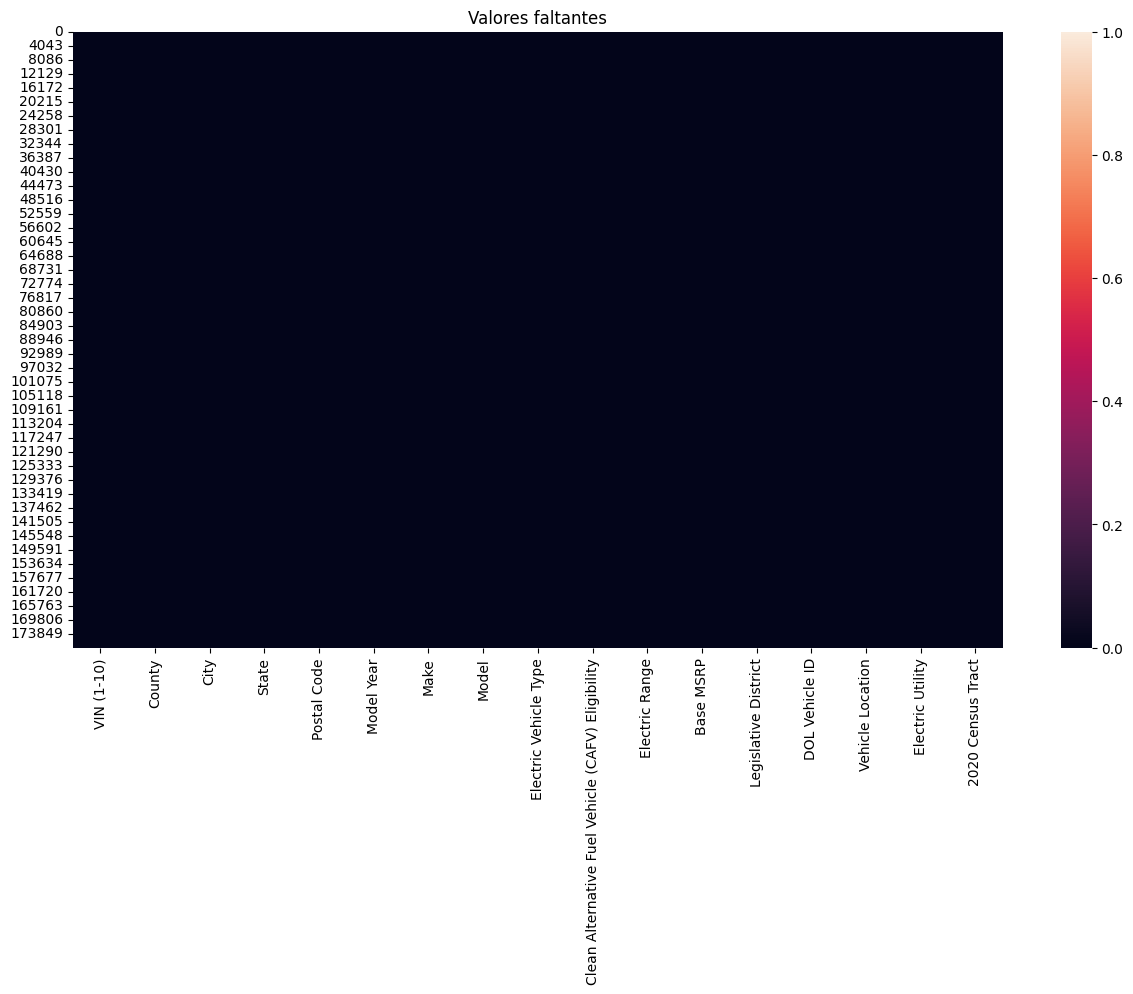

In [188]:
#Revision de Valores nulos con mapa de calor
fig,axes = plt.subplots(figsize=(15,8))
sns.heatmap(df_evp.isnull())
plt.title("Valores faltantes");


<Axes: >

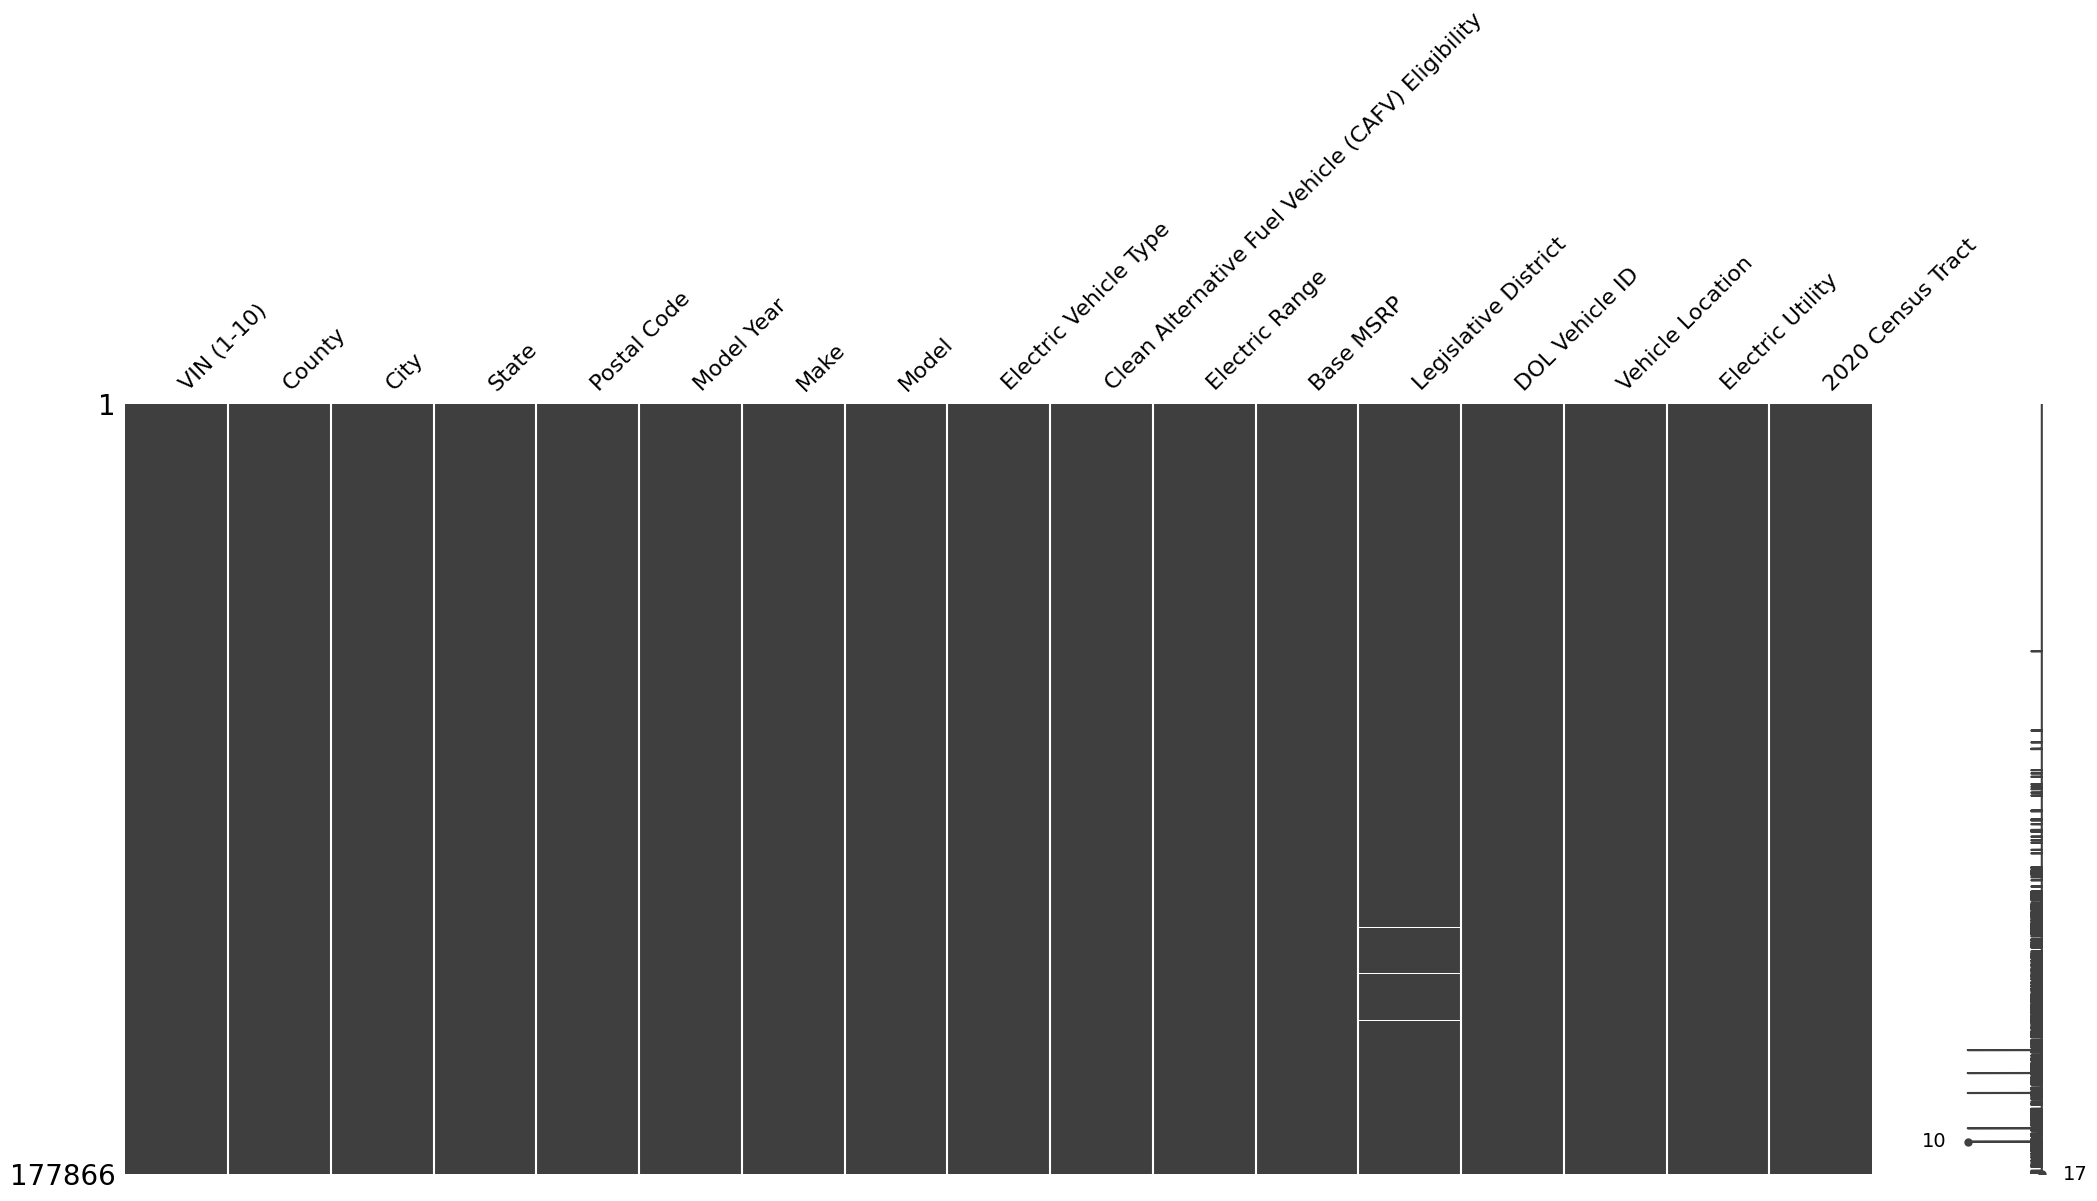

In [189]:
#Visualizar Valores faltantes por medio de una matriz y lineas
msno.matrix(df_evp)

<Axes: >

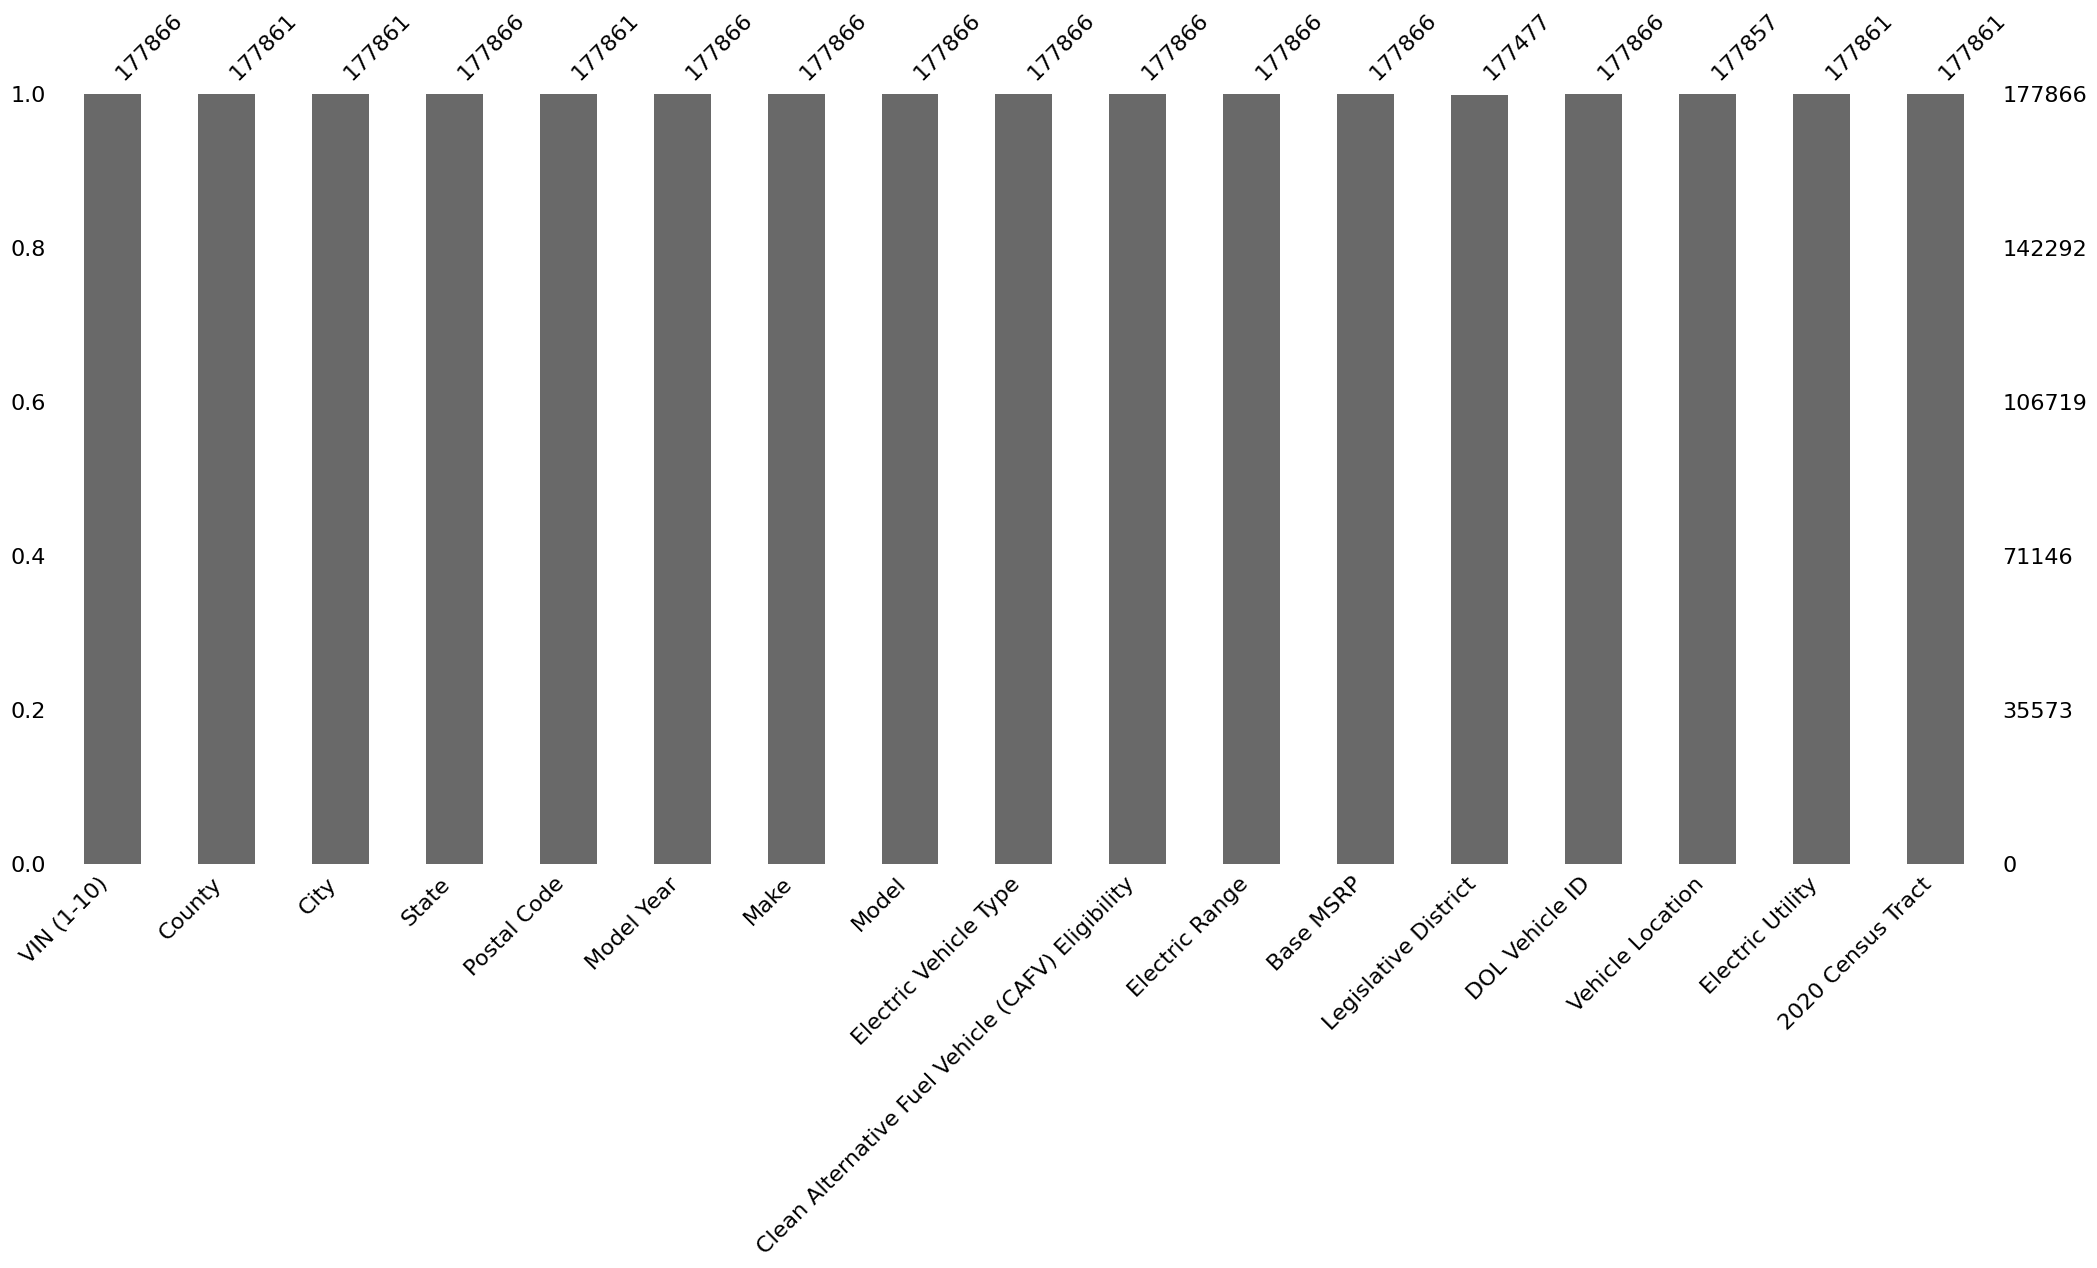

In [190]:
#Observar valores faltantes ocn grafica de barras
msno.bar(df_evp)

In [191]:
# Verificar valores nulos por columna de texto
columnas_texto = ['County','City', 'Postal Code','Legislative District','Vehicle Location','Electric Utility','2020 Census Tract']
print(df_evp[columnas_texto].isnull().sum())

County                    5
City                      5
Postal Code               5
Legislative District    389
Vehicle Location          9
Electric Utility          5
2020 Census Tract         5
dtype: int64


In [192]:
# Imputación de datos por director
# Es preferible usar una nuevo director que borrar los registros
#Los registros de la columa County tipo object que eran NaN se llenaran con el texto 'sin director'
#Los registros de la columna cast tipo text que eran Nan se llenaran con el texto 'sin cast'
#Los registros de la columna country tipo text que eran Nan se llenaran con el texto 'sin pais'


df_evp['County'] = df_evp['County'].fillna('Not County')
df_evp['City'] = df_evp['City'].fillna('Not City')
df_evp['Postal Code'] = df_evp['Postal Code'].fillna('0.0')
df_evp['Legislative District'] = df_evp['Legislative District'].fillna('0')
df_evp['Vehicle Location'] = df_evp['Vehicle Location'].fillna('NOT POINT')
df_evp['Electric Utility'] = df_evp['Electric Utility'].fillna('Not Utility')
df_evp['2020 Census Tract'] = df_evp['2020 Census Tract'].fillna('0.0')

In [193]:

print(df_evp[columnas_texto].isnull().sum())

County                  0
City                    0
Postal Code             0
Legislative District    0
Vehicle Location        0
Electric Utility        0
2020 Census Tract       0
dtype: int64


In [194]:
#Volvemos a ver como esta la info
df_evp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177866 entries, 0 to 177865
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype 
---  ------                                             --------------   ----- 
 0   VIN (1-10)                                         177866 non-null  object
 1   County                                             177866 non-null  object
 2   City                                               177866 non-null  object
 3   State                                              177866 non-null  object
 4   Postal Code                                        177866 non-null  object
 5   Model Year                                         177866 non-null  int64 
 6   Make                                               177866 non-null  object
 7   Model                                              177866 non-null  object
 8   Electric Vehicle Type                              177866 non-null  object
 9   Clea

In [195]:
#Obsevamos si hay valores nullos
df_evp.isna()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177861,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
177862,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
177863,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
177864,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [196]:
# Detección de duplicados y valores nulos por columna
#Para ver los datos duplicados
df_evp.duplicated().sum()


np.int64(0)

In [197]:
# En este caso nos devuelve la suma de nulos
df_evp.isna().sum()

,0
VIN (1-10),0
County,0
City,0
State,0
Postal Code,0
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


**ANALISIS UNIVARIABLE**

In [198]:
# Mostrar resumen estadístico
df_evp.describe()

,Model Year,Electric Range,Base MSRP,DOL Vehicle ID
count,177866.000000,177866.000000,177866.000000,1.778660e+05
mean,2020.515512,58.842162,1073.109363,2.202313e+08
std,2.989384,91.981298,8358.624956,7.584987e+07
min,1997.000000,0.000000,0.000000,4.385000e+03
25%,2019.000000,0.000000,0.000000,1.814743e+08
50%,2022.000000,0.000000,0.000000,2.282522e+08
75%,2023.000000,75.000000,0.000000,2.548445e+08
max,2024.000000,337.000000,845000.000000,4.792548e+08


In [199]:
# Realizar una proporción de probabilidad

media = round(df_evp.describe()['Electric Range']['mean'], 4)
std= round(df_evp.describe()['Electric Range']['std'], 4)
prop_prob = round((std/media)*100, 1)

print(f'Los datos se separan de la medía a un {prop_prob}%')

Los datos se separan de la medía a un 156.3%


**MEDIDA DE TENDENCIA CENTRAL**

In [200]:
# Definir variables
media = round(df_evp['Electric Range'].mean(), 2)
mediana = round(df_evp['Electric Range'].median(), 2)
moda = round(df_evp['Electric Range'].mode().iloc[0], 2)

print(f'Las MTC son: media {media}, mediana {mediana} y moda {moda}')

Las MTC son: media 58.84, mediana 0.0 y moda 0


In [201]:
# Definir variables Rango Electrico
media_re = round(df_evp['Electric Range'].mean(),2)
mediana_re = round(df_evp['Electric Range'].median(),2)
moda_re = df_evp['Electric Range'].mode()[0]

In [202]:
# Definir listas Rango Electrico
mtc_datos_re = [media_re, mediana_re, moda_re]
mtc_colores_re = ['blue', 'red', 'green']
mtc_etiquetas_re = ['media', 'mediana', 'moda']

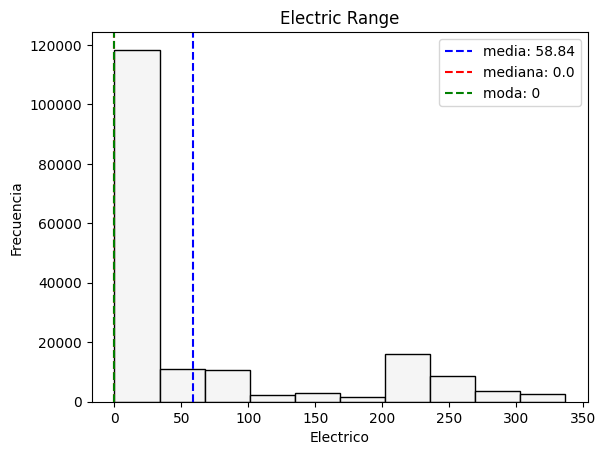

In [203]:
#Grafica de Histograma del Rango Electrico
plt.hist(df_evp['Electric Range'], edgecolor = 'black',color = 'whitesmoke')
plt.title('Electric Range')
plt.xlabel('Electrico')
plt.ylabel('Frecuencia')

for dato, color, etiqueta in zip(mtc_datos_re, mtc_colores_re, mtc_etiquetas_re):
    plt.axvline(x = dato, c = color, linestyle = '--', label = f'{etiqueta}: {dato}')
#plt.axvline(x = dato, c = color, linestyle = '--', label = f'{etiqueta}: {dato}')

plt.legend()
plt.show()

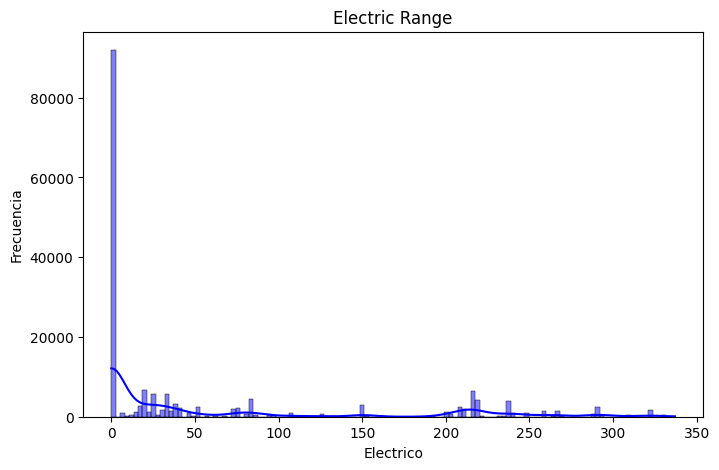

In [204]:
# Gráfico de distribución del Rango Electrico
plt.figure(figsize=(8, 5))
sns.histplot(df_evp['Electric Range'], kde=True, color='blue')
plt.title('Electric Range')
plt.xlabel('Electrico')
plt.ylabel('Frecuencia')
plt.show()

In [205]:
# Definir variables Model Year
media_my = round(df_evp['Model Year'].mean(),2)
mediana_my = round(df_evp['Model Year'].median(),2)
moda_my = df_evp['Model Year'].mode()[0]


In [206]:
# Definir listas Model Year
mtc_datos_my = [media_my, mediana_my, moda_my]
mtc_colores_my = ['blue', 'red', 'green']
mtc_etiquetas_my = ['media', 'mediana', 'moda']

In [207]:
# Definir listas Model Year
mtc_datos_my = [media_my, mediana_my, moda_my]
mtc_colores_my = ['blue', 'red', 'green']
mtc_etiquetas_my = ['media', 'mediana', 'moda']

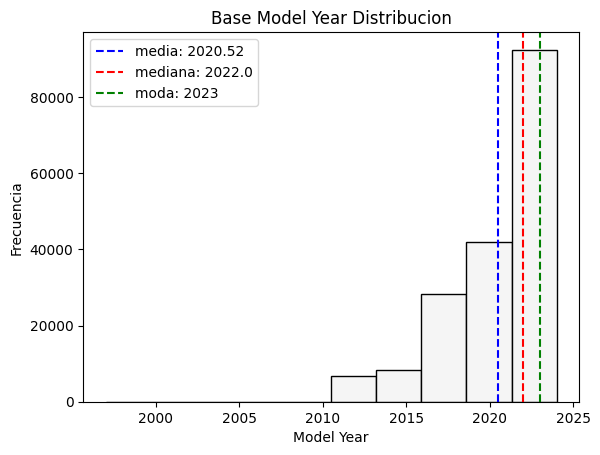

In [208]:
#Grafica de Histograma de Model Year
plt.hist(df_evp['Model Year'], edgecolor = 'black',color = 'whitesmoke')
plt.title('Base Model Year Distribucion')
plt.xlabel('Model Year')
plt.ylabel('Frecuencia')

for dato, color, etiqueta in zip(mtc_datos_my, mtc_colores_my, mtc_etiquetas_my):
    plt.axvline(x = dato, c = color, linestyle = '--', label = f'{etiqueta}: {dato}')
#plt.axvline(x = dato, c = color, linestyle = '--', label = f'{etiqueta}: {dato}')

plt.legend()
plt.show()

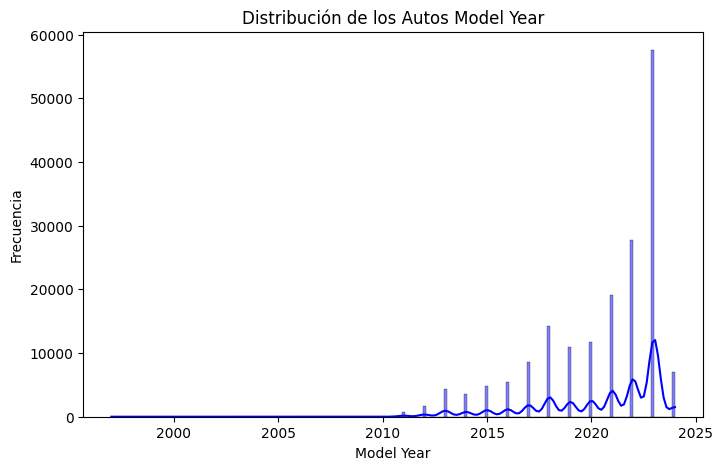

In [209]:
# Gráfico de distribución de Model Year
plt.figure(figsize=(8, 5))
sns.histplot(df_evp['Model Year'], kde=True, color='blue')
plt.title('Distribución de los Autos Model Year')
plt.xlabel('Model Year')
plt.ylabel('Frecuencia')
plt.show()

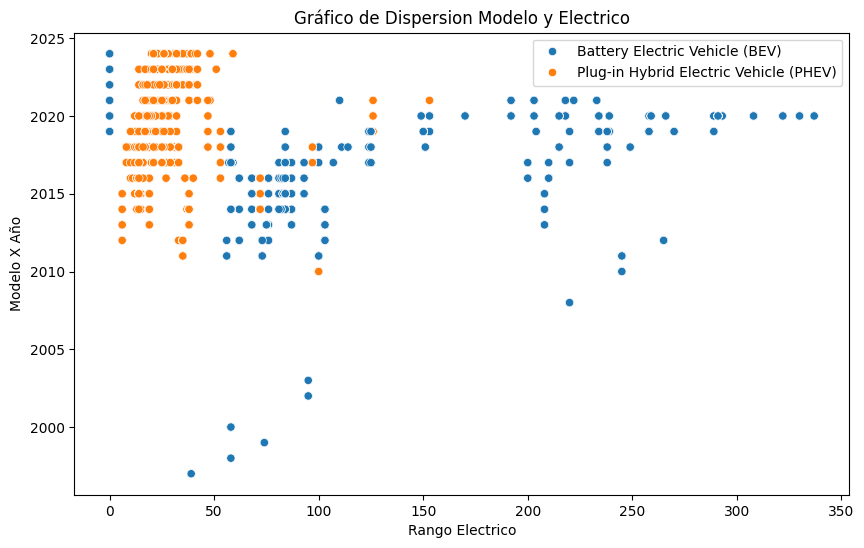

In [210]:
#Grafica de la Electrilc Range vs Model Year
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_evp, x='Electric Range', y='Model Year', hue='Electric Vehicle Type')
plt.title('Gráfico de Dispersion Modelo y Electrico')
plt.xlabel('Rango Electrico')
plt.ylabel('Modelo X Año')
plt.legend()
plt.show()

**DESVIACION** **ESTANDAR**

In [211]:
#std Electric Range
# Definir variables
x_er = range(len(df_evp['Electric Range']))
y_er = df_evp['Electric Range']
std_er = np.std(df_evp['Electric Range'])


In [212]:
# Definir Electric Range
std_datos_er = [media_re, mediana_re + std , media_re - std ]
std_colores_er = ['red', 'blue', 'blue']
std_etiquetas_er = ['mediana', 'desviacion standar', None]

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


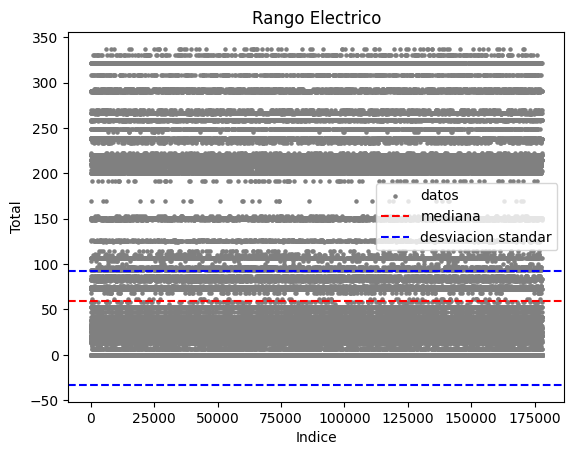

In [213]:

#Grafica de dispersion Rango Electrico
plt.scatter(x_er, y_er, color = 'gray', s = 5, label = 'datos')
plt.title('Rango Electrico')
plt.xlabel('Indice')
plt.ylabel('Total')

for dato, color, etiqueta in zip(std_datos_er, std_colores_er, std_etiquetas_er):
  plt.axhline(y = dato, c = color, linestyle = '--', label = etiqueta)

plt.legend()
plt.show()

In [218]:
#std Model Year
# Definir variables
x_my = range(len(df_evp['Model Year']))
y_my = df_evp['Model Year']
std_my = np.std(df_evp['Model Year'])

In [219]:
# Definir listas Model Year
std_datos_my = [media_my, mediana_my + std_my , media_my - std_my ]
std_colores_my = ['red', 'blue', 'blue']
std_etiquetas_my = ['mediana', 'desviacion standar', None]

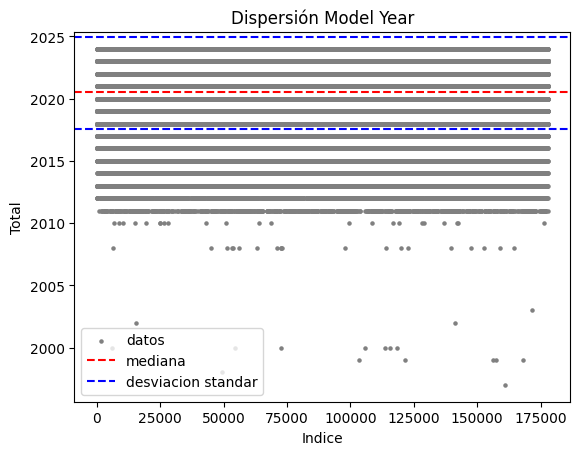

In [221]:
#Grafica de dispersion del Model Year
plt.scatter(x_my, y_my, color = 'gray', s = 5, label = 'datos')
plt.title('Dispersión Model Year')
plt.xlabel('Indice')
plt.ylabel('Total')

for dato, color, etiqueta in zip(std_datos_my, std_colores_my, std_etiquetas_my):
  plt.axhline(y = dato, c = color, linestyle = '--', label = etiqueta)

plt.legend()

**PERCENTILES**

In [223]:
# Percentiles Rango Electrico
percentil = np.percentile(df_evp['Electric Range'],[25,50,75])

q_1 = round(percentil[0],2)
q_3 = round(percentil[2],2)
iqr = round(q_3 - q_1,2)


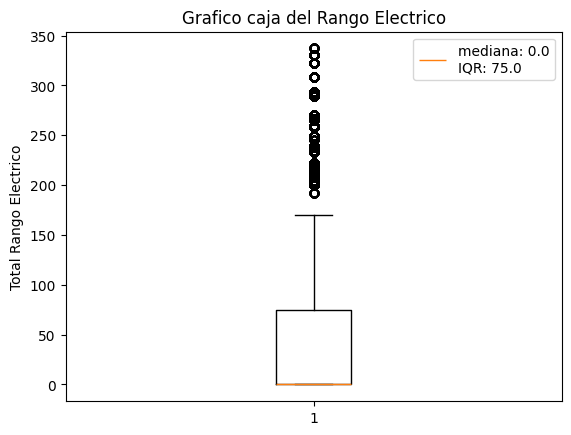

In [224]:
# Visualizar percentiles Rango Electrico
plt.boxplot(df_evp['Electric Range'], label= f'mediana: {mediana_re}\nIQR: {iqr}')
plt.title('Grafico caja del Rango Electrico')
plt.ylabel('Total Rango Electrico')
plt.legend()
plt.show()

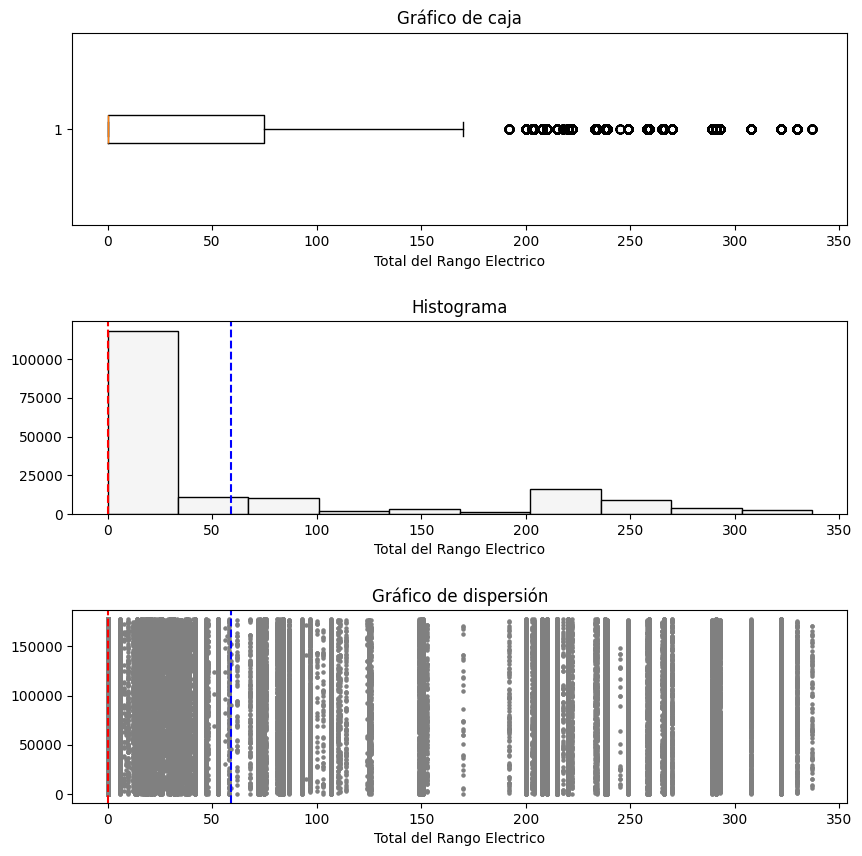

In [227]:
# Asociar gráficos Rango Electrico
fig, ax = plt.subplots(3, figsize = (10, 10), gridspec_kw = {'hspace':0.5})

ax[0].boxplot(df_evp['Electric Range'], vert = False)
ax[0].set_title('Gráfico de caja')
ax[0].set_xlabel('Total del Rango Electrico')


ax[1].hist(df_evp['Electric Range'], edgecolor = 'black',color = 'whitesmoke')
ax[1].axvline(x = media_re, color = 'blue', linestyle = '--')
ax[1].axvline(x = mediana_re, color = 'red', linestyle = '--')
ax[1].set_title('Histograma')
ax[1].set_xlabel('Total del Rango Electrico')

ax[2].scatter(y_er, x_er, color = 'gray', s = 5)
ax[2].axvline(x = media_re, color = 'blue', linestyle = '--')
ax[2].axvline(x = mediana_re, color = 'red', linestyle = '--')
ax[2].set_title('Gráfico de dispersión')
ax[2].set_xlabel('Total del Rango Electrico')

plt.show()

In [229]:
# Percentiles Model Year
percentil = np.percentile(df_evp['Model Year'],[25,50,75])

q_1 = round(percentil[0],2)
q_3 = round(percentil[2],2)
iqr = round(q_3 - q_1,2)

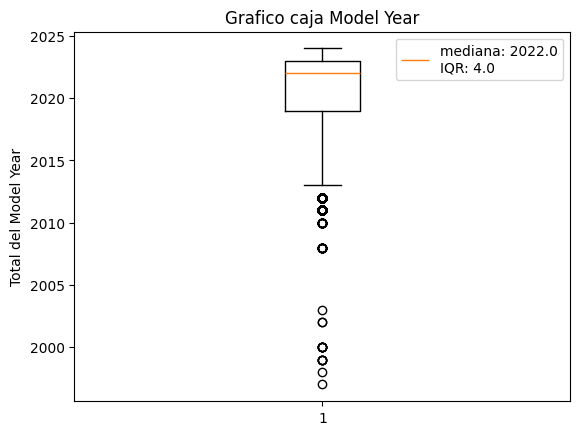

In [230]:
# Visualizar percentiles Model Year
plt.boxplot(df_evp['Model Year'], label= f'mediana: {mediana_my}\nIQR: {iqr}')
plt.title('Grafico caja Model Year')
plt.ylabel('Total del Model Year')
plt.legend()
plt.show()

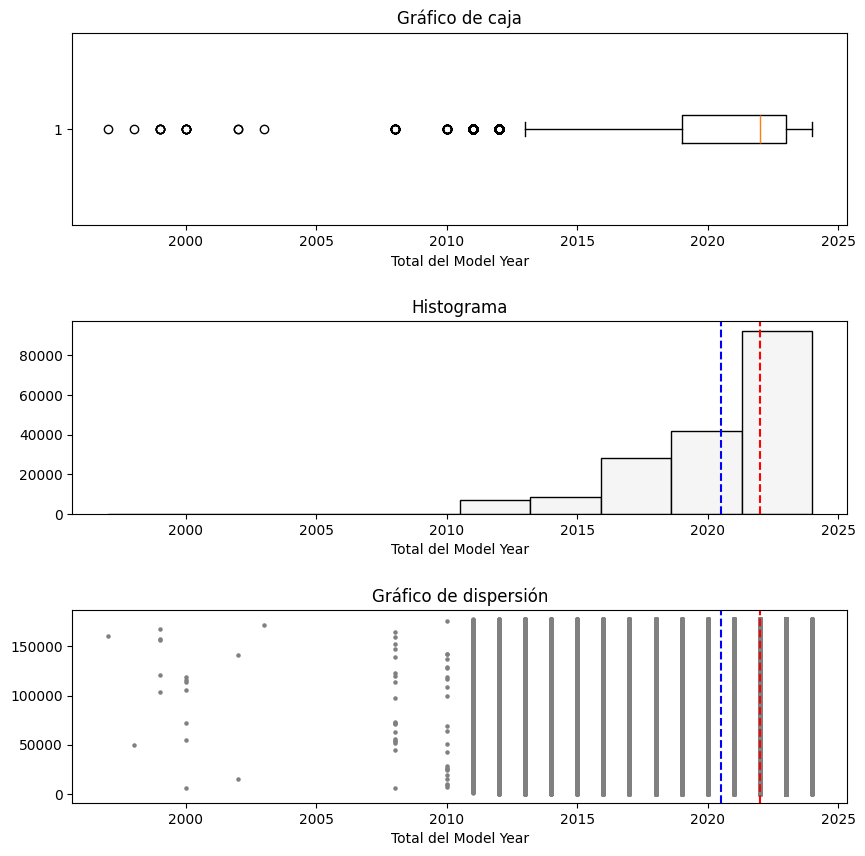

In [232]:
# Asociar gráficos Model  Year
fig, ax = plt.subplots(3, figsize = (10, 10), gridspec_kw = {'hspace':0.5})

ax[0].boxplot(df_evp['Model Year'], vert = False)
ax[0].set_title('Gráfico de caja')
ax[0].set_xlabel('Total del Model Year')


ax[1].hist(df_evp['Model Year'], edgecolor = 'black',color = 'whitesmoke')
ax[1].axvline(x = media_my, color = 'blue', linestyle = '--')
ax[1].axvline(x = mediana_my, color = 'red', linestyle = '--')
ax[1].set_title('Histograma')
ax[1].set_xlabel('Total del Model Year')


ax[2].scatter(y_my, x_my, color = 'gray', s = 5)
ax[2].axvline(x = media_my, color = 'blue', linestyle = '--')
ax[2].axvline(x = mediana_my, color = 'red', linestyle = '--')
ax[2].set_title('Gráfico de dispersión')
ax[2].set_xlabel('Total del Model Year')

plt.show()

In [233]:
df_evp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177866 entries, 0 to 177865
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype 
---  ------                                             --------------   ----- 
 0   VIN (1-10)                                         177866 non-null  object
 1   County                                             177866 non-null  object
 2   City                                               177866 non-null  object
 3   State                                              177866 non-null  object
 4   Postal Code                                        177866 non-null  object
 5   Model Year                                         177866 non-null  int64 
 6   Make                                               177866 non-null  object
 7   Model                                              177866 non-null  object
 8   Electric Vehicle Type                              177866 non-null  object
 9   Clea

**ANÁLISIS BIVARIABLE**

In [234]:
#Para el mapa de calor y coorelacion
columnas = ['Model Year', 'Electric Range', 'Base MSRP', 'DOL Vehicle ID']
correlacion = df_evp[columnas].corr()

long_col = len(columnas)

**COORELACION**

In [235]:
correlacion

,Model Year,Electric Range,Base MSRP,DOL Vehicle ID
Model Year,1.000000,-0.476852,-0.230492,0.134835
Electric Range,-0.476852,1.000000,0.108231,-0.093874
Base MSRP,-0.230492,0.108231,1.000000,-0.027383
DOL Vehicle ID,0.134835,-0.093874,-0.027383,1.000000


**MULTIVARIABLE**

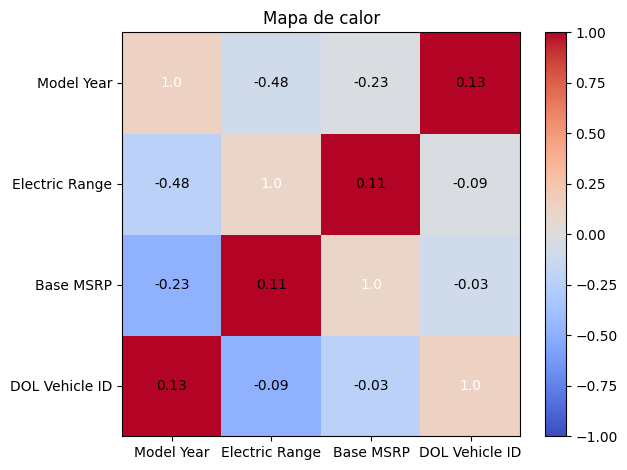

In [236]:
# Visualizar mapa de calor
corr_inv = correlacion.iloc[::-1]
heatmap = plt.pcolor(correlacion, cmap = 'coolwarm', vmin = -1, vmax = 1)
plt.title('Mapa de calor')
plt.xticks(np.arange(0.5, long_col, 1), columnas)
plt.yticks(np.arange(0.5, long_col, 1), columnas[::-1])

for i in range(len(columnas)):
  for j in range(len(columnas)):
    val = round(corr_inv.iloc[i,j],2)
    plt.text(j + 0.5, i + 0.5, f'{val}',
             ha = 'center', va = 'center',
             color = 'white' if abs(val) > 0.6 else 'black')

   # print(val)

plt.colorbar(heatmap)
plt.tight_layout()
plt.show()

<Axes: >

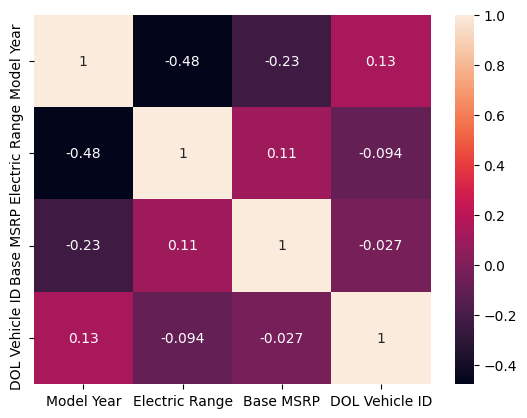

In [237]:
# Mapa de calor que muestra la correlación entre las variables numéricas del dataset
sns.heatmap(df_evp[columnas].corr(), annot = True)

**BIVARIABLE**

In [238]:
# Definir variables
corr_er_my = round(df_evp['Electric Range'].corr(df_evp['Model Year']),2),
corr_er_msrp = round(df_evp['Electric Range'].corr(df_evp['Base MSRP']),2),
corr_msrp_dolId =round(df_evp['Base MSRP'].corr(df_evp['DOL Vehicle ID']),2),

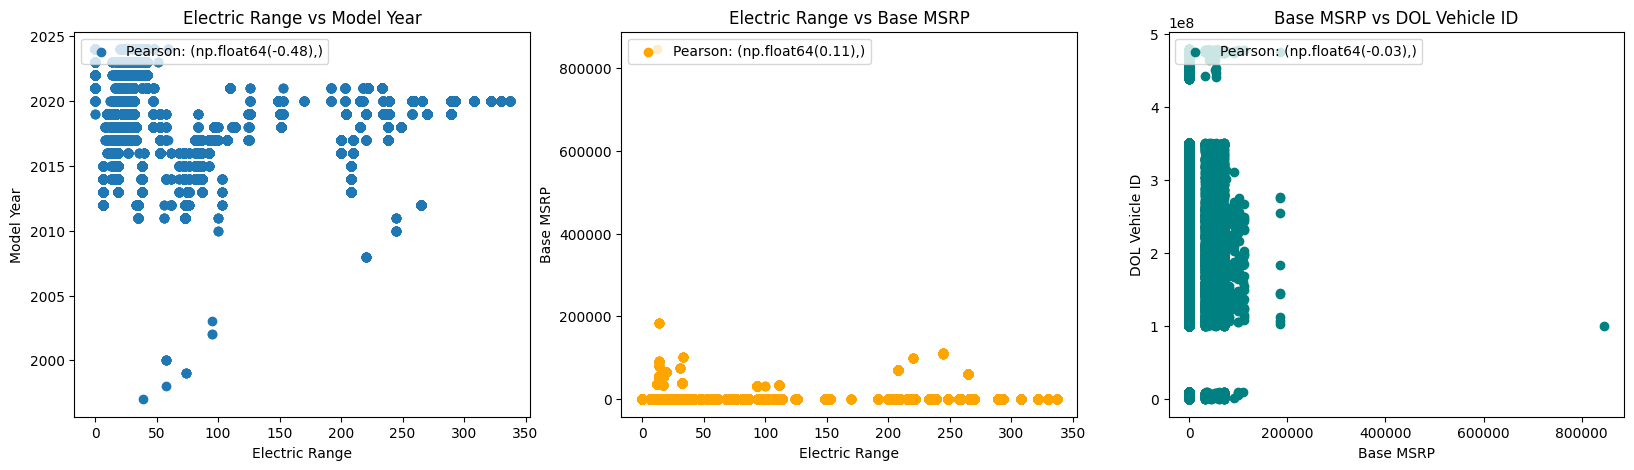

In [239]:
# Visualizar correlaciones
fig, ax = plt.subplots(1, 3, figsize = (20, 5), gridspec_kw = {'hspace': 0.5})

ax[0].scatter(data = df_evp, x = 'Electric Range', y = 'Model Year', label = f'Pearson: {corr_er_my}')
ax[0].set_title('Electric Range vs Model Year')
ax[0].set_xlabel('Electric Range')
ax[0].set_ylabel('Model Year')
ax[0].legend(loc = 'upper left')

ax[1].scatter(data = df_evp, x = 'Electric Range', y = 'Base MSRP', color = 'orange', label = f'Pearson: {corr_er_msrp}')
ax[1].set_title('Electric Range vs Base MSRP')
ax[1].set_xlabel('Electric Range')
ax[1].set_ylabel('Base MSRP')
ax[1].legend(loc = 'upper left')

ax[2].scatter(data = df_evp, x = 'Base MSRP', y = 'DOL Vehicle ID', color = 'teal', label = f'Pearson: {corr_msrp_dolId}')
ax[2].set_title('Base MSRP vs DOL Vehicle ID')
ax[2].set_xlabel('Base MSRP')
ax[2].set_ylabel('DOL Vehicle ID')
ax[2].legend(loc = 'upper left')

plt.show()

**ANALISIS PREDICTIVO DE DATOS**

In [245]:
# Definir regresión lineal
x = df_evp['Electric Range']
y = df_evp['Model Year']
n = len(x)

linear_regression = np.polyfit(x, y, 1)
beta, alpha = linear_regression

print(f'y = {beta:.2f} x + {alpha:.2f}')

y = -0.02 x + 2021.43


In [246]:
# Realizar algoritmo del descenso de gradiente

tamaño_paso = 0.001
theta_0 = 0
theta_1 = 0

perdida = []
num_iteraciones = 100

for i in range(num_iteraciones):
    y_pred = theta_1 * x + theta_0
    error = ((y_pred - y) ** 2).mean()
    perdida.append(error)

    d_theta_0 = (2 / n) * np.sum(y_pred - y)
    d_theta_1 = (2 / n) * np.sum((y_pred - y) * x)

    theta_0 = theta_0 - tamaño_paso * d_theta_0
    theta_1 = theta_1 - tamaño_paso * d_theta_1

print(f'y = {theta_1:.2f} x + {theta_0:.2f}')

y = -75873453416482573792714301205441097626079796335917041230283423038067150236405019067683138250276628568874415738920735248249744078332231680.00 x + -374474282401033047954761382150166753158816849491411198187281847338238553754786932387103995222680624412841101440506639255436748839190528.00


In [247]:
# Predicción de valores con descenso de gradiente

glucosa = int(input('Agrega el valor Año: '))
pred_glc = round(theta_1 * glucosa + theta_0, 2)

print(f'El rango electrico es {pred_glc}')

Agrega el valor Año: 2025
El rango electrico es -1.5364411764265962e+140


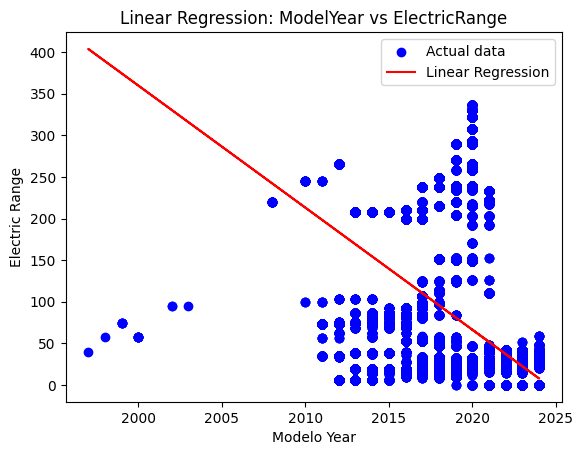

In [252]:
#Para la Regresion Lineal
# import from sklearn the linear regression model that will help us in this analysis.

from sklearn.linear_model import LinearRegression

# Define X (independent variable) and y (dependent variable) for linear regression
X = df_evp['Model Year'].values.reshape(-1, 1) # Reshape to 2D array
y = df_evp['Electric Range'].values

# create an empty linear regression model like below and give it a good variable name
linear_model = LinearRegression()

# to create the model, we use fit(X,y)
linear_model.fit(X, y)


y_pred = linear_model.predict(X)
plt.scatter(X, y, color = 'b', label='Actual data')
plt.plot(X, y_pred, color = 'r', label='Linear Regression')
plt.title('Linear Regression: ModelYear vs ElectricRange')
plt.xlabel('Modelo Year')
plt.ylabel('Electric Range')
plt.legend()
plt.show()

**RANDOM FOREST**

In [253]:
# 1 Para este ejemplo práctico, predeciremos el tipo de vehículo: 'Electric Vehicle Type'
X = df_evp.drop(columns=['Electric Vehicle Type'])
y = df_evp['Electric Vehicle Type']

In [254]:
# 2. Definición de características numéricas y categóricas
numeric_features = ['Model Year', 'Electric Range', 'Base MSRP']
categorical_features = ['County', 'Make']

In [255]:
# 3. Preprocesamiento de datos (Pipeline de transformación)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [256]:
# 4. Creación del Pipeline completo con un Clasificador Random Forest
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10))
])

In [257]:
# 5. División de los datos en conjuntos de Entrenamiento y Prueba (Train/Test Split)
# Nota: En el dataset real (177,867 filas), el split del 20% proveerá un robusto set de validación.

# Identificar y remover clases con un solo miembro para permitir la estratificación
class_counts = y.value_counts()
problematic_classes = class_counts[class_counts < 2].index

if not problematic_classes.empty:
    # Filtrar X y y para excluir filas con clases problemáticas
    # Asegurar que X y y estén alineados después del filtrado
    y_filtered = y[~y.isin(problematic_classes)]
    X_filtered = X.loc[y_filtered.index]
else:
    X_filtered = X
    y_filtered = y

X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered)


In [258]:
# 6. Entrenamiento del Modelo Clasificador
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Model Year',
                                                   'Electric Range',
                                                   'Base MSRP']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['County', 'Make'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=10, random_state=42))])

In [259]:
# 7. Evaluación de Predicciones
y_pred = model_pipeline.predict(X_test)

print("--- Evaluación del Clasificador de Vehículos Eléctricos ---")
print(f"Accuracy General: {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

--- Evaluación del Clasificador de Vehículos Eléctricos ---
Accuracy General: 0.9814

Reporte de Clasificación:
                                        precision    recall  f1-score   support

        Battery Electric Vehicle (BEV)       0.98      1.00      0.99     27843
Plug-in Hybrid Electric Vehicle (PHEV)       1.00      0.92      0.96      7731

                              accuracy                           0.98     35574
                             macro avg       0.99      0.96      0.97     35574
                          weighted avg       0.98      0.98      0.98     35574

